In [207]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

In [208]:
url = "https://raw.githubusercontent.com/AbhipriyaSingh/Creditcard_fraud_detection/main/fraud_data.csv"


df = pd.read_csv(url)
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [209]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long
count,14446.000000,14446.000000,14446.000000,1.444600e+04,14446.000000,14446.000000
mean,124.430073,39.787692,-110.874225,1.065370e+05,39.787991,-110.874892
std,231.352587,5.317039,12.985813,2.902916e+05,5.360593,12.995596
min,1.000000,20.027100,-165.672300,4.600000e+01,19.032689,-166.670685
25%,12.080000,36.715400,-120.415800,4.930000e+02,36.794655,-120.146253
50%,51.520000,39.666200,-111.098500,1.645000e+03,39.620953,-111.192629
75%,101.030000,41.940400,-101.136000,3.543900e+04,42.275740,-100.446822
max,3261.470000,66.693300,-89.628700,2.383912e+06,67.510267,-88.646366


In [210]:
df.shape

(14446, 15)

In [211]:
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [212]:
category_counts = df.groupby('is_fraud').size().reset_index(name='count')

print(category_counts)

                 is_fraud  count
0                       0  12600
1  0"2019-01-01 00:00:44"      1
2                       1   1844
3  1"2020-12-24 16:56:24"      1


In [213]:
df['is_fraud'].unique()

array(['1', '1"2020-12-24 16:56:24"', '0', '0"2019-01-01 00:00:44"'],
      dtype=object)

#### since is_fraud column has some weird values, we will remove the outlier values

In [214]:
df = df[(df['is_fraud'] == "1") | (df['is_fraud'] == "0")]

df.shape


(14444, 15)

In [215]:
category_counts = df.groupby('is_fraud').size().reset_index(name='count')

print(category_counts)

  is_fraud  count
0        0  12600
1        1   1844


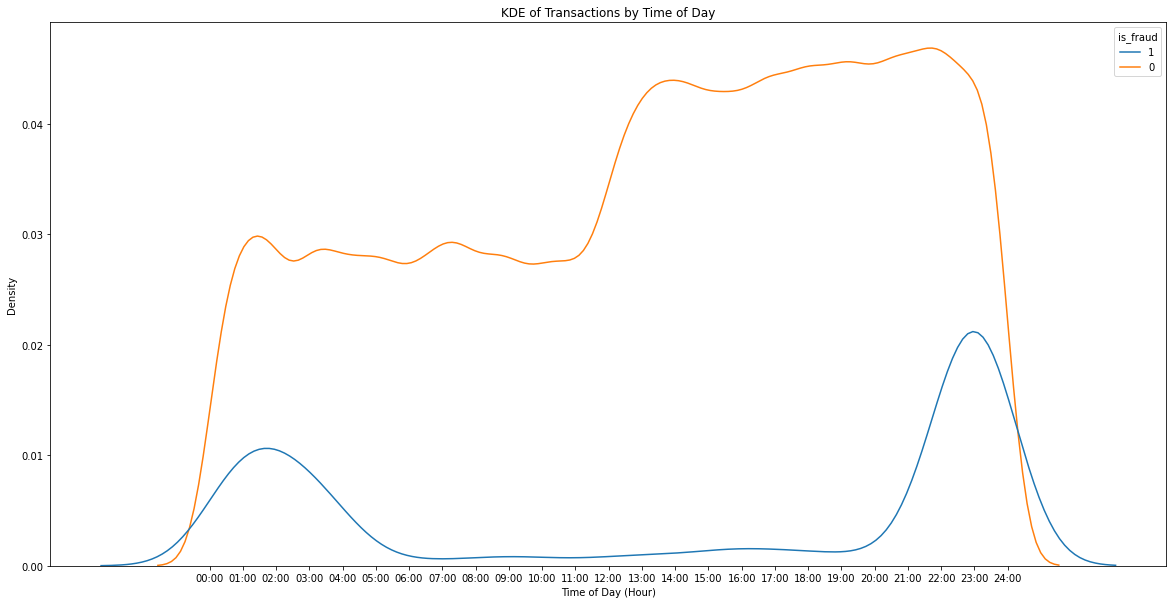

In [216]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour_decimal'] = df['trans_date_trans_time'].dt.hour + df['trans_date_trans_time'].dt.minute / 60
plt.figure(figsize=(20, 10))

sns.kdeplot(data=df, x='hour_decimal', hue='is_fraud', bw_adjust=0.5)
plt.xlabel('Time of Day (Hour)')
plt.title('KDE of Transactions by Time of Day')
plt.xticks(ticks=range(0, 25), labels=[f'{h:02d}:00' for h in range(0, 25)])
plt.show()

In [217]:
df.dtypes

trans_date_trans_time    datetime64[ns]
merchant                         object
category                         object
amt                             float64
city                             object
state                            object
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                              object
trans_num                        object
merch_lat                       float64
merch_long                      float64
is_fraud                         object
hour_decimal                    float64
dtype: object

In [218]:
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, str)).mean() > 0.9:
        print(f"{col}")


merchant
category
city
state
job
dob
trans_num
is_fraud


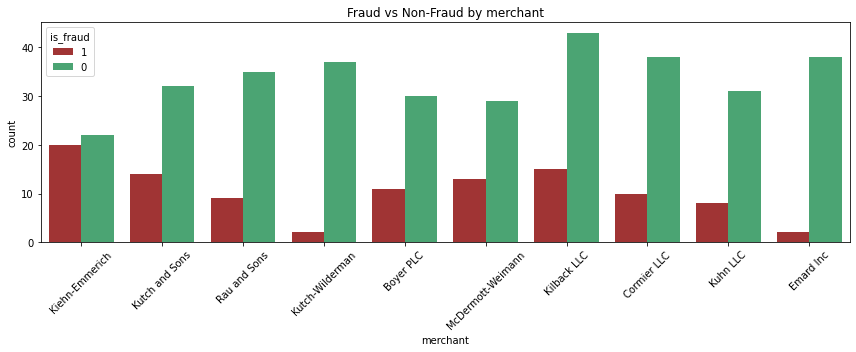

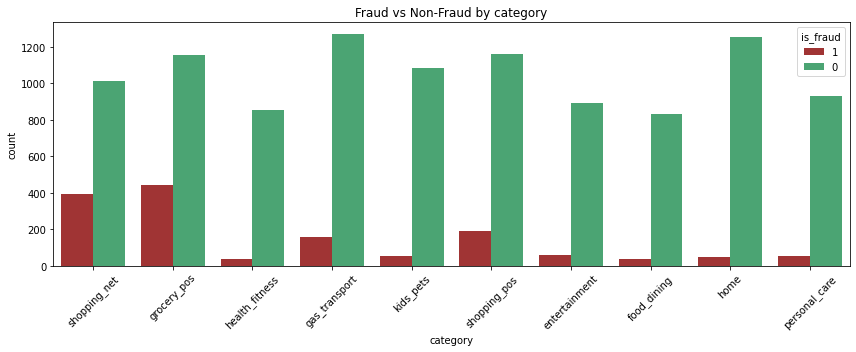

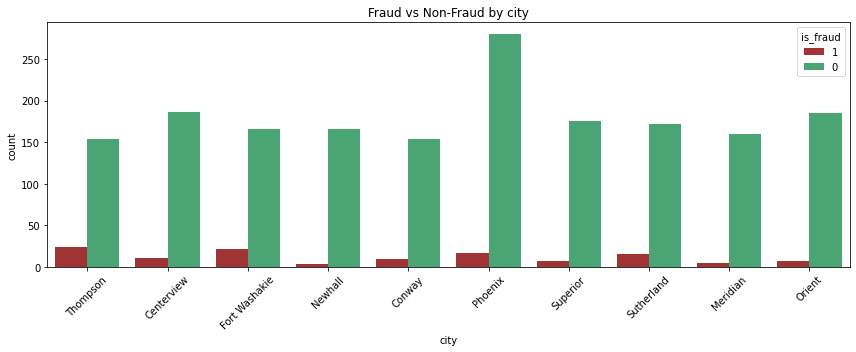

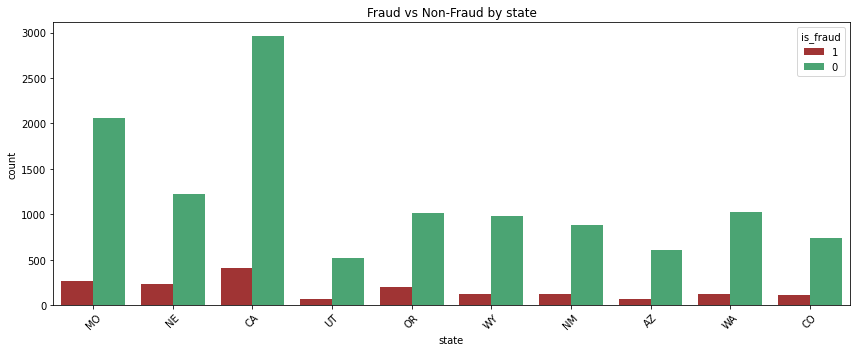

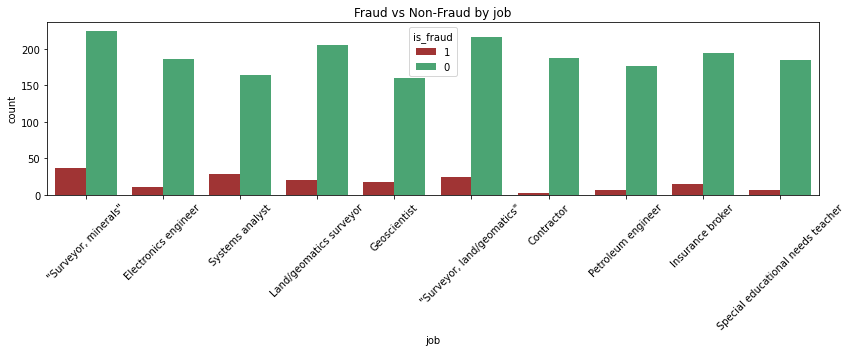

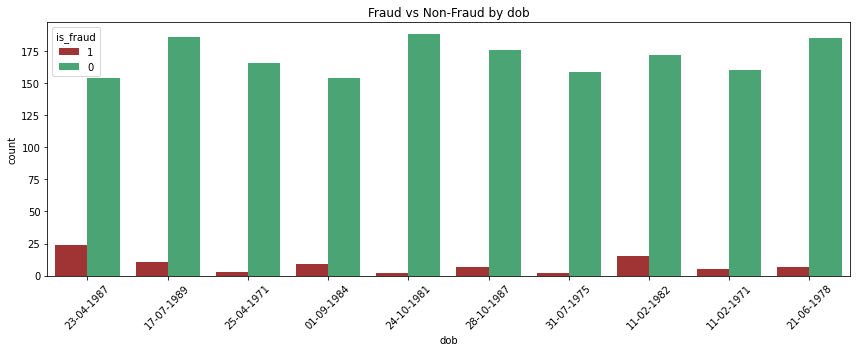

In [219]:
string_cols = ["merchant","category","city","state","job","dob"]

def plot_fraud_by_string_columns(df, string_cols, target_col='is_fraud', top_n=10):
    """
    Plots bar charts of top N categories in string columns vs is_fraud flag.

    Parameters:
    - df: pandas DataFrame
    - string_cols: list of string column names to plot
    - target_col: name of the target column (default is 'is_fraud')
    - top_n: number of top categories to show per column
    """
    for col in string_cols:
        # Get top N categories to keep the plot readable
        
        custom_colors = {
            '0': '#3CB371',  # steel blue
            '1': '#B22222',  # lime green
        }
        top_categories = df[col].value_counts().nlargest(top_n).index
        filtered_df = df[df[col].isin(top_categories)]

        plt.figure(figsize=(12, 5))
        sns.countplot(data=filtered_df, x=col, hue=target_col, palette= custom_colors)
        plt.title(f'Fraud vs Non-Fraud by {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    
plot_fraud_by_string_columns(df, string_cols)


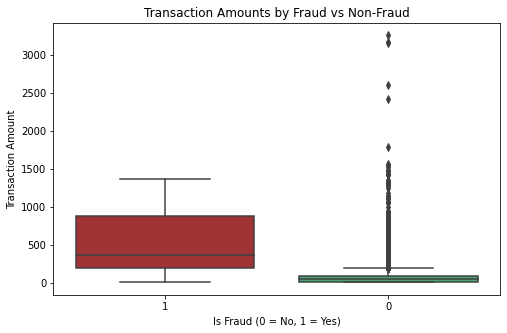

In [220]:
custom_colors = {
            '0': '#3CB371',  
            '1': '#B22222',  
        }

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_fraud', y='amt', palette= custom_colors)
plt.title('Transaction Amounts by Fraud vs Non-Fraud')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount')
plt.show()

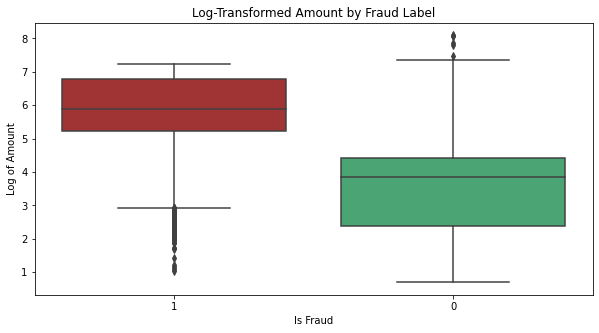

In [221]:
df['log_amount'] = np.log1p(df['amt'])
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_fraud', y='log_amount', palette= custom_colors)  # red and green
plt.title("Log-Transformed Amount by Fraud Label")
plt.xlabel("Is Fraud")
plt.ylabel("Log of Amount")
plt.show()


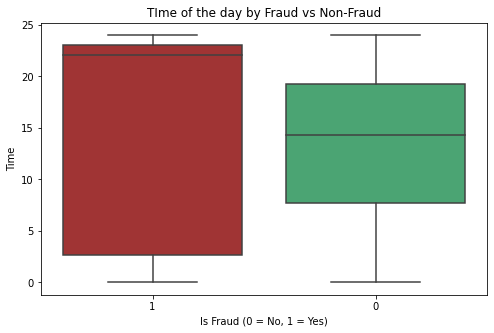

In [222]:
custom_colors = {
            '0': '#3CB371',  
            '1': '#B22222',  
        }

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_fraud', y='hour_decimal', palette= custom_colors)
plt.title('TIme of the day by Fraud vs Non-Fraud')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Time')
plt.show()

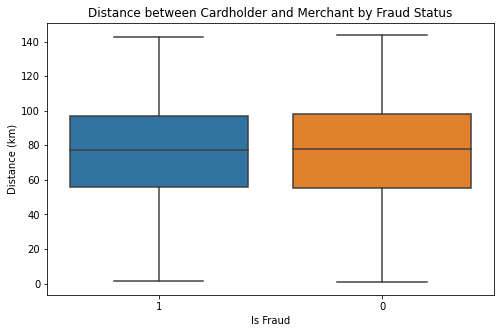

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


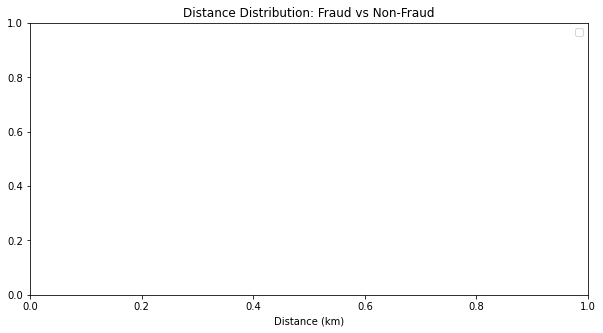

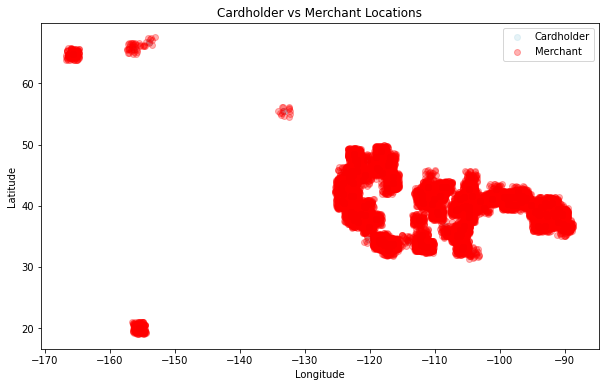

In [223]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c  # distance in km

# Create a distance column
df['distance_km'] = haversine_distance(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
)


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_fraud', y='distance_km')
plt.title('Distance between Cardholder and Merchant by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Distance (km)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_fraud'] == 0]['distance_km'], label='Not Fraud', fill=True)
sns.kdeplot(data=df[df['is_fraud'] == 1]['distance_km'], label='Fraud', fill=True, color='red')
plt.title('Distance Distribution: Fraud vs Non-Fraud')
plt.xlabel('Distance (km)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df['long'], df['lat'], c='lightblue', alpha=0.3, label='Cardholder')
plt.scatter(df['merch_long'], df['merch_lat'], c='red', alpha=0.3, label='Merchant')
plt.title("Cardholder vs Merchant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

In [224]:
df['log_city_pop'] = np.log1p(df['city_pop'])


In [225]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,hour_decimal,log_amount,distance_km,log_city_pop
count,14444.000000,14444.000000,14444.000000,1.444400e+04,14444.000000,14444.000000,14444.000000,14444.000000,14444.000000,14444.000000
mean,124.445403,39.787408,-110.873004,1.065510e+05,39.787704,-110.873659,13.526642,3.776043,75.825980,8.245983
std,231.364927,5.317251,12.986241,2.903093e+05,5.360821,12.996034,7.294435,1.481614,28.717699,2.793693
min,1.000000,20.027100,-165.672300,4.600000e+01,19.032689,-166.670685,0.000000,0.693147,0.639325,3.850148
25%,12.080000,36.715400,-120.415800,4.930000e+02,36.794014,-120.143697,7.200000,2.571084,55.438978,6.202536
50%,51.540000,39.666200,-111.098500,1.645000e+03,39.620953,-111.191458,14.550000,3.961575,77.946241,7.406103
75%,101.032500,41.940400,-101.136000,3.543900e+04,42.275042,-100.443743,20.016667,4.625291,97.719597,10.475596
max,3261.470000,66.693300,-89.628700,2.383912e+06,67.510267,-88.646366,23.983333,8.090240,143.559991,14.684254


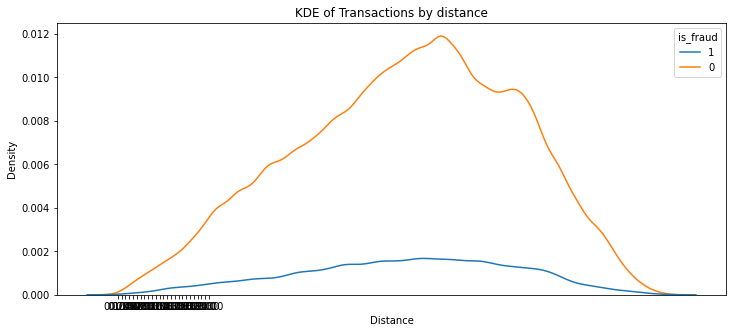

In [206]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='distance_km', hue='is_fraud', bw_adjust=0.5)
plt.xlabel('Distance')
plt.title('KDE of Transactions by distance')
plt.xticks(ticks=range(0, 25), labels=[f'{h:02d}:00' for h in range(0, 25)])
plt.show()

In [226]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- Step 1: Preprocess Data ---


# List of categorical columns
categorical_cols = ["merchant","category","city","state","job","dob"]  # example

# Apply Label Encoding to categorical columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # store encoder if needed for inverse transform

# --- Step 2: Define Features and Target ---

# Choose relevant features (adjust as needed)
feature_cols = ['log_amount'] + categorical_cols + ['hour_decimal'] + ['distance_km'] + ['log_city_pop'] # example features
X = df[feature_cols]
y = df['is_fraud']

# --- Step 3: Train-Test Split ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# --- Step 4: Scale Numeric Features ---

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 5: Apply SMOTE to Training Set Only ---

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

# --- Step 6: Train Model ---

clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train_resampled, y_train_resampled)

# --- Step 7: Evaluate on Test Set ---

y_pred = clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2520
           1       0.90      0.91      0.90       369

    accuracy                           0.98      2889
   macro avg       0.94      0.95      0.95      2889
weighted avg       0.98      0.98      0.98      2889

